In [1]:
import math
import random
import matplotlib.pyplot as plt

def generate_normal(mu, sigma):
    u1= random.random()
    u2=random.random()

    z=math.sqrt(-2*math.log(u1))*math.cos(2*math.pi*u2)
    return mu+sigma*z
                
    

In [2]:
n=50
true_mean=10
true_sd=3

rainfall=[generate_normal(true_mean,true_sd) for _ in range(n)]
rainfall[:5]



[12.67625980791166,
 7.6586981956634075,
 8.80102413306257,
 5.667523670187265,
 10.214300774240842]

In [3]:
sample_mean=sum(rainfall)/n
SE= true_sd/math.sqrt(n)
z=1.96

lower_CI= sample_mean-z*SE
upper_CI= sample_mean+z*SE

sample_mean, (lower_CI, upper_CI)

(10.36358916327585, (9.532031588600471, 11.19514673795123))

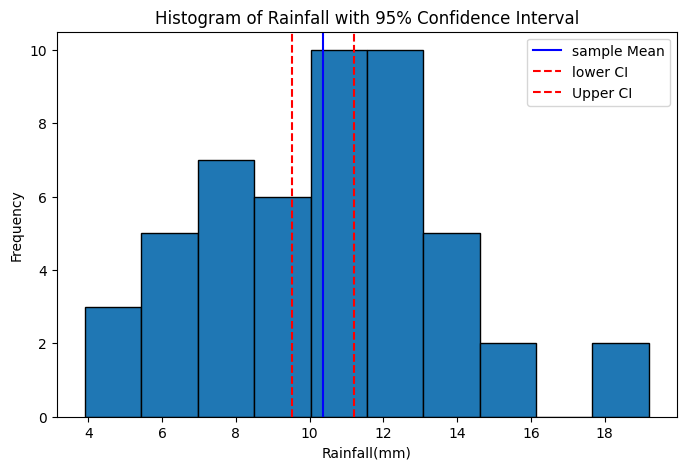

In [4]:
plt.figure(figsize=(8,5))
plt.hist(rainfall, bins=10, edgecolor='black')

plt.axvline(sample_mean, color='blue', label='sample Mean')
plt.axvline(lower_CI, color='red', linestyle='--', label='lower CI')
plt.axvline(upper_CI,color='red', linestyle='--', label='Upper CI')

plt.title("Histogram of Rainfall with 95% Confidence Interval")
plt.xlabel("Rainfall(mm)")
plt.ylabel("Frequency")
plt.legend()
plt.show()
           


In [5]:
num_sim=100
CIs=[]
contains_true=[]

for i in range(num_sim):
    sample=[generate_normal(true_mean, true_sd) for _ in range(n)]
    mean_i=sum(sample)/n
    variance_i=sum((x-mean_i)**2 for x in sample) /(n-1)
    sd_i=math.sqrt(variance_i)
    SE_i=sd_i/ math.sqrt(n)

    L=mean_i-z*SE_i
    U=mean_i+z*SE_i
 
    CIs.append((L, U))
    contains_true.append(L <=true_mean <=U)

sum(contains_true)

    

95

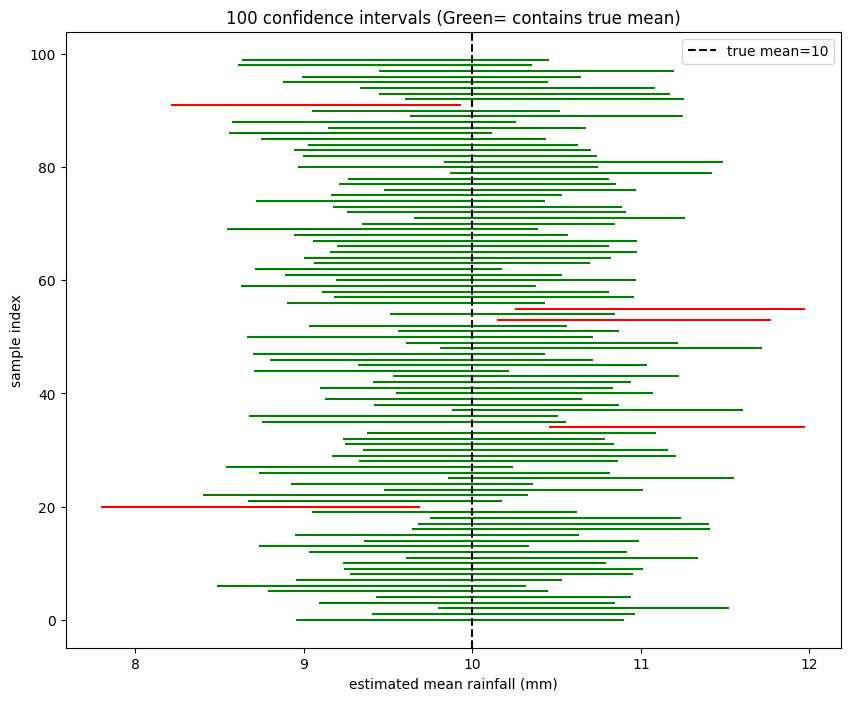

In [6]:
plt.figure(figsize=(10,8))

for i, (L,U) in enumerate(CIs):
    color='green' if contains_true[i] else 'red'
    plt.hlines(y=i, xmin=L, xmax=U, colors=color)

plt.axvline(true_mean, color='black', linestyle='--', label='true mean=10')

plt.title("100 confidence intervals (Green= contains true mean)")
plt.xlabel("estimated mean rainfall (mm)")
plt.ylabel("sample index")
plt.legend()
plt.show()
